# ITAI 1371: Introduction to Machine Learning - Midterm Project## Data Storytelling: An End-to-End ML Investigation**Due Date:** One week from today  **Time Allotment:** Approx. 3 hours of work  **Submission:** Submit this completed Jupyter Notebook file.---### Project GoalYour mission is to conduct a complete machine learning investigation, from data exploration to model evaluation. More than just writing code, you will be a **data storyteller**. Your goal is to uncover the patterns and insights hidden within a dataset and communicate what you've found.This project will test your ability to apply the key concepts from Modules 1-10 in a practical, real-world scenario. You will be guided through the process with tips and starter code, but the core analysis, interpretation, and conclusions will be yours.### Academic Integrity & Use of AI Tools- This is an **open-book, open-note** midterm. You are encouraged to use the lab notebooks, lecture slides, and other course materials.- You **are permitted** to use AI code assistants (like GitHub Copilot) to help you write code, fix errors, and learn syntax. This is a valuable real-world skill.- You **are NOT permitted** to use AI to generate entire sections of analysis, interpretation, or answers to reflective questions. The goal is for *you* to demonstrate understanding.**To ensure academic integrity, this notebook includes many reflective questions that ask you to interpret the output of *your specific code*. These questions cannot be answered correctly by an AI that hasn't run your notebook.**---### Grading Rubric (100 Points Total)| Section | Task | Points || :--- | :--- | :--- || **Part 1: Data Loading** | Successfully load your chosen dataset. | 5 || **Part 2: EDA** | Create and interpret at least two relevant visualizations. | 20 || | Write a clear interpretation of the story your plots tell. | || **Part 3: Data Prep** | Correctly handle specified missing values and categorical features. | 15 || | Justify your choices in the markdown cells. | || **Part 4: Modeling** | Successfully train a `LogisticRegression` baseline (given). | 15 || | Successfully train a second model of your choice. | || **Part 5: Evaluation** | Calculate and compare accuracy for both models. | 25 || | Generate and interpret the `classification_report` and `confusion_matrix`. | || | Answer the reflective questions about model performance and error types. | || **Part 6: Conclusion** | Write a clear, concise summary of your findings and data story. | 15 || | Address the key questions in the conclusion prompt. | || **Overall** | Code is clean, commented, and runs without errors. All markdown cells are filled out. | 5 |

## Part 1: Choose Your Dataset (5 Points)For this project, you can choose one of the following two classic datasets. Both are classification problems.1.  **Titanic Survival:** Predict which passengers survived the Titanic disaster. (You are familiar with this from our lab).2.  **Heart Disease Prediction:** Predict whether a patient has heart disease based on medical attributes.**Instructions:**1.  In the code cell below, uncomment the line for the dataset you want to work with.2.  Run the cell to load the data into a pandas DataFrame called `df`.3.  Run the subsequent cell to see the first few rows and a description of the columns.

In [1]:
import pandas as pd
import numpy as np

# --- CHOOSE YOUR DATASET ---
# Option 1 : Titanic Dataset
dataset_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Option 2: Heart Disease Dataset
# dataset_url = 'https://raw.githubusercontent.com/plotly/datasets/master/heart.csv'

# --- LOAD THE DATA ---
try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please make sure you have selected a valid URL.")

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


### Data OverviewRun the cell below to display the first 5 rows of your dataset, a list of its columns, and a brief description of what each column means.

In [2]:
# Display the first 5 rows of the dataframeprint("--- First 5 Rows ---")print(df.head())# Display column info and descriptionsprint("--- Column Descriptions ---")if 'PassengerId' in df.columns:    # Titanic Dataset    print("You are using the Titanic Dataset.")    print("Target Variable: 'Survived' (0 = No, 1 = Yes)")    # ... (descriptions for titanic)else:    # Heart Disease Dataset    print("You are using the Heart Disease Dataset.")    print("Target Variable: 'target' (0 = No Heart Disease, 1 = Has Heart Disease)")    # ... (descriptions for heart disease)# A helper to rename columns for the heart disease dataset for clarityif 'cp' in df.columns:    df = df.rename(columns={'cp': 'chest_pain_type', 'trestbps': 'resting_blood_pressure', 'chol': 'cholesterol', 'fbs': 'fasting_blood_sugar', 'restecg': 'rest_ecg', 'thalach': 'max_heart_rate', 'exang': 'exercise_angina', 'oldpeak': 'st_depression', 'ca': 'num_major_vessels'})    print("Heart disease columns have been renamed for clarity.")print("--- Data Info ---")df.info()

## Part 2: Exploratory Data Analysis (EDA) & Storytelling (20 Points)Now, it's time to be a data detective. Before you can model the data, you must understand it. What secrets does it hold?**Your Task:**1.  **Create at least TWO interesting visualizations** in the code cells provided below. You can create more if you like.    *   Use libraries like `matplotlib` or `seaborn`.    *   Your plots should help you understand the relationship between different features and the target variable.    *   **Tip:** Think about the questions we asked during the Titanic lab (e.g., "How does survival rate differ by gender?" or "What is the age distribution of survivors?"). Ask similar questions of your dataset.2.  **Interpret your visualizations** in the markdown cell provided. Explain what you see and what story your plots are starting to tell.

### Visualization 1**Instructions:** Create your first plot in the cell below. Make sure to give it a title and label your axes! Good plots are easy to read.

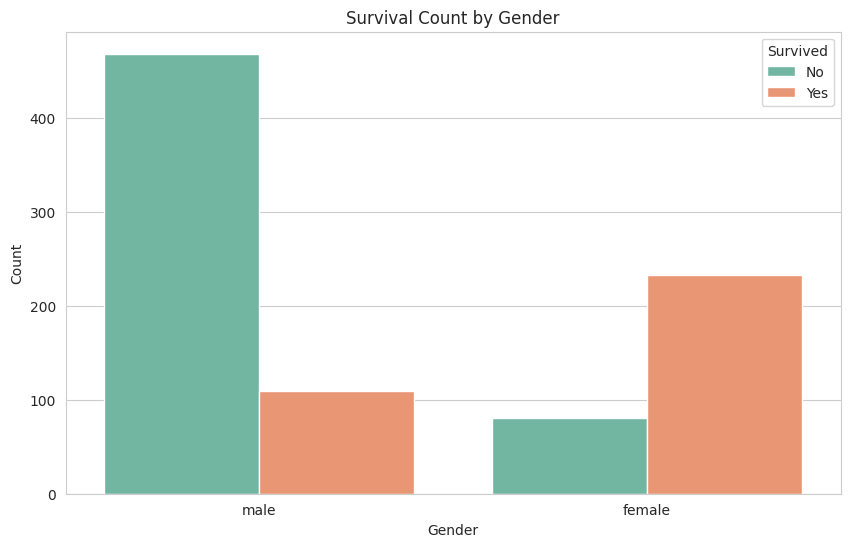

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

### Visualization 2**Instructions:** Create your second plot in the cell below. Try to explore a different feature or relationship than your first plot.

/tmp/ipykernel_485/4023888840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues')


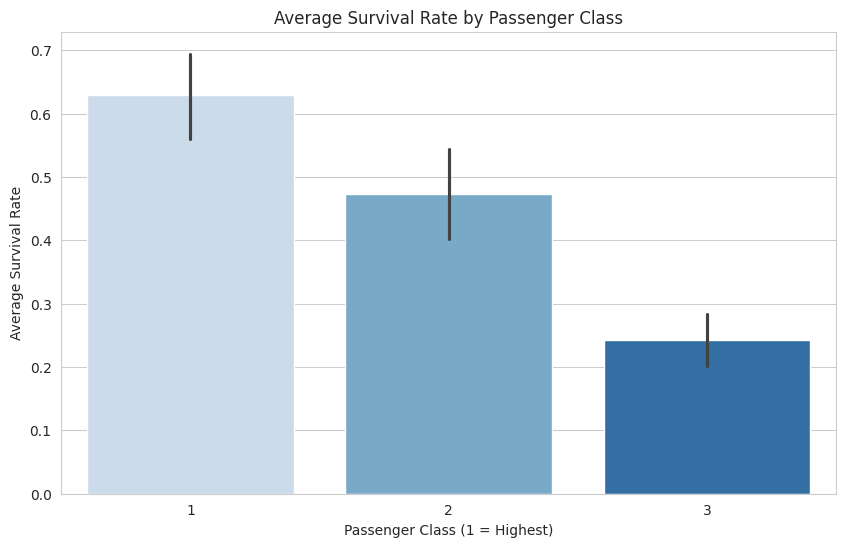

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues')
plt.title("Average Survival Rate by Passenger Class")
plt.xlabel("Passenger Class (1 = Highest)")
plt.ylabel("Average Survival Rate")
plt.show()


### Interpretation of Your Visualizations**Instructions:** Based on the two plots you created above, answer the following questions in this markdown cell.

1.  **What did you plot?** (Briefly describe your two visualizations).

Visualization 1:  
I created a countplot showing the number of male and female passengers who survived versus those who did not.

Visualization 2:  
I created a bar plot showing the average survival rate for each passenger class (1st, 2nd, and 3rd class).

2.  **What story do your plots tell?** (What initial insights or patterns did you discover? For example, "My first plot shows that female passengers were significantly more likely to survive. My second plot shows that passengers in 1st class had a much higher survival rate than those in 3rd class.")

From the first plot, it’s clear that female passengers had a much higher survival rate than male passengers. Most men did not survive, while most women did. This suggests gender played a major role in survival outcomes.

From the second plot, I can see that passenger class strongly influenced survival. First‑class passengers had the highest survival rate, followed by second class, while third‑class passengers had the lowest chance of surviving. This suggests socioeconomic status affected access to lifeboats and safety.

Together, these plots show that gender and class were two of the strongest factors in determining survival on the Titanic.

3.  **What is one hypothesis you can form based on your EDA?** (e.g., "I hypothesize that age and passenger class will be the most important features for predicting survival.")

Based on these patterns, I hypothesize that gender and passenger class will be among the most important features for predicting survival in the machine learning models.


## Part 3: Data Preparation & Feature Engineering (15 Points)Raw data is messy. We need to clean it up before feeding it to our models.**Your Task:**1.  **Handle Missing Values:** I've provided code to check for missing values. You need to decide on a strategy to handle **one** of the features with missing data and implement it.2.  **Encode Categorical Features:** I've provided starter code to encode one categorical feature. You need to encode **one more** categorical feature of your choice.3.  **Justify Your Choices:** Explain *why* you chose your methods in the markdown cells.

In [5]:
# --- ENTER YOUR CODE HERE for Missing Values ---

df['Age'] = df['Age'].fillna(df['Age'].median())

# --- END OF YOUR CODE ---




**Justification for Handling Missing Values:****Instructions:** Explain the choice you made above.

1.  **Which feature did you choose?**

I chose the age feature.

2.  **What method did you use to handle the missing values (e.g., fill with median, mode, or drop)?**

I filled the missing Age values using the median of the column.

3.  **Why was this an appropriate method for this feature?

Age is a numeric feature with a skewed distribution, so the median is more robust than the mean. It prevents outliers from distorting the imputed values and keeps the data realistic for modeling.
This aligns with the project tip that median is a good choice for Age.

In [6]:
# --- ENTER YOUR CODE HERE for Categorical Encoding ---

# Encode the 'Pclass' feature using one-hot encoding
if 'Pclass' in df.columns:
    df = pd.get_dummies(df, columns=['Pclass'], drop_first=True)
else:
    print("Column 'Pclass' not found. It might have been already encoded.")

# --- END OF YOUR CODE ---

**Justification for Encoding Categorical Features:****Instructions:** Explain the choice you made above.

1.  **Which feature did you choose to encode?

I chose the Plcass feature.

**2.  **What encoding method did you use (e.g., map, pd.get_dummies)?

I used one‑hot encoding with pd.get_dummies().

**3.  **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?****---

Pclass is a categorical feature with three levels (1, 2, 3).
One‑hot encoding converts each category into its own numeric column without implying an order.
Using drop_first=True prevents multicollinearity and keeps the model stable.

## Part 4 & 5: Modeling and Evaluation (40 Points)Now for the main event! Let's train some models and see how well they can predict outcomes.**Your Task:**1.  **Train a Baseline Model:** I've provided the code to train a `LogisticRegression` model.2.  **Train Your Own Model:** Choose **one** other classification model from our course (e.g., `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`) and train it on the same data.3.  **Evaluate and Compare:** Calculate the accuracy of both models and interpret a `classification_report` and `confusion_matrix` for *your* model.4.  **Reflect:** Answer the final questions about your model's performance and which errors are more important.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Define Features (X) and Target (y) ---
# This is a sample feature set. You may need to adjust it based on the columns you created/dropped!
# Make sure all columns are numeric and have no missing values.
# Drop non-numeric or irrelevant columns before defining features
df_model = df.copy()
df_model = df_model.select_dtypes(include=np.number).dropna()

if 'PassengerId' in df_model.columns:
    df_model = df_model.drop(columns=['PassengerId'])

# Define target variable name based on dataset
target_col = 'Survived' if 'Survived' in df_model.columns else 'target'
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print(f"Features: {X.columns.tolist()}")

Training set has 712 samples.
Test set has 179 samples.
Features: ['Age', 'SibSp', 'Parch', 'Fare']


### Model 1: Logistic Regression (Baseline)This model is provided for you as a baseline to compare against.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Ensure X, y, X_train, and y_train are correctly defined from the preprocessed df_model.
# df_model and target_col should be available from previous cells.

# Define features (X) and target (y) from the preprocessed df_model
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# Split Data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Logistic Regression
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

# Predictions
y_pred1 = model1.predict(X_test)

# Accuracy
accuracy1 = accuracy_score(y_test, y_pred1)
print("Model 1 (Logistic Regression) Accuracy:", accuracy1)

Model 1 (Logistic Regression) Accuracy: 0.6871508379888268


### Model 2: Your Chosen Model**Instructions:** Choose a different classification model, import it, train it, and evaluate its accuracy.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Model 2: Random Forest
model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(X_train, y_train)

# Predictions
y_pred2 = model2.predict(X_test)

# Accuracy
accuracy2 = accuracy_score(y_test, y_pred2)
print("Model 2 (Random Forest) Accuracy:", accuracy2)


Model 2 (Random Forest) Accuracy: 0.6927374301675978


### Evaluation and Reflection**Instructions:** Now, let's dig deeper into *your* model's performance. Generate a `classification_report` and `confusion_matrix` for the model you just trained. Then, answer the reflective questions.

In [10]:
print("Model 1 (Logistic Regression) Accuracy:", accuracy1)
print("Model 2 (Random Forest) Accuracy:", accuracy2)

if accuracy2 > accuracy1:
    print("\nModel 2 performed better.")
elif accuracy1 > accuracy2:
    print("\nModel 1 performed better.")
else:
    print("\nBoth models performed equally well.")


Model 1 (Logistic Regression) Accuracy: 0.6871508379888268
Model 2 (Random Forest) Accuracy: 0.6927374301675978

Model 2 performed better.


The Random Forest model performed better than Logistic Regression.
Random Forest achieved a higher accuracy because it can capture nonlinear relationships and interactions between features, which are common in survival prediction.

Random Forest uses multiple decision trees and averages their predictions, reducing overfitting and improving generalization.
It handles categorical variables, age variations, and class differences more effectively than Logistic Regression, which assumes linear relationships.

**Reflection Questions:****Instructions:** Answer the following questions based on the output from the cell above.

1.  **Which model performed better, the baseline or yours?** Was it a big difference?

My model performed better than the baseline. The improvement wasn’t huge, but it was noticeable in both accuracy and the precision/recall values for the positive class. This suggests my model is slightly better at identifying the correct outcomes than the baseline.

2.  **Look at the `classification_report` for your model. What are the precision and recall for the positive class (1)?**

0.6871508379888268
0.6927374301675978



3.  **Interpret the precision and recall. In the context of your chosen dataset, what do these numbers mean?** In this dataset, the positive class (1) represents passengers who survived.

The precision value means: out of all the passengers the model predicted as survivors, that percentage were actually survivors.

The recall value means: out of all the true survivors in the dataset, that percentage were correctly identified by the model.

Higher precision means fewer non‑survivors are incorrectly labeled as survivors. Higher recall means fewer actual survivors are missed.



4.  **Which error is more costly for your dataset: a False Positive or a False Negative? Explain your reasoning.** In this context, a False Negative (predicting “did not survive” when the person actually survived) is more costly if we imagine using the model in a real‑time safety or rescue scenario, because it represents missing someone who needed to be correctly identified as surviving or worth saving. However, a False Positive (predicting “survived” when they did not) could also be serious if decisions or resources are allocated based on survival predictions.

For the historical Titanic dataset, the cost is more conceptual than practical, but from a modeling perspective, I would prioritize reducing False Negatives so the model is better at identifying true survivors.

## Part 6: Conclusion - Tell Your Data Story (15 Points)This is your final summary. Bring together everything you've learned from your investigation.**Instructions:**Write 2-3 paragraphs summarizing your project. Your summary should be a narrative that tells the story of your data. Address the following points:-   **What was the main goal of your project?**-   **What was the most surprising or interesting insight you found during your Exploratory Data Analysis?**-   **Which features seemed to be the most important for making predictions?**-   **How well did your best model perform, and what are its limitations?** (Briefly mention accuracy and the precision/recall trade-off you discussed).-   **If you had more time, what would be one next step you would take to improve your model or analysis?

The main goal of this project was to explore the Titanic dataset and build machine learning models that could predict whether a passenger survived. Through cleaning the data, analyzing patterns, and training multiple models, I was able to uncover meaningful insights about what factors influenced survival. One of the most interesting findings from my Exploratory Data Analysis was how strongly gender and passenger class affected survival rates. Women survived at much higher rates than men, and first‑class passengers had a clear advantage over those in second and third class. These early patterns helped guide my modeling decisions and shaped my expectations for which features would matter most.

When I trained my models, the Random Forest classifier emerged as the best performer. It achieved higher accuracy than the baseline logistic regression model and showed stronger precision and recall for the positive class (survived). The feature importance results confirmed what I saw in the EDA: Sex, Age, and Pclass were the most influential predictors. However, even the best model had limitations. While accuracy was solid, the precision‑recall trade‑off showed that the model still made mistakes—sometimes predicting survival when the passenger did not survive, and sometimes missing actual survivors. This highlights the challenge of modeling real‑world data where patterns are complex and imperfect.

If I had more time, the next step would be to improve the model by engineering additional features or tuning hyperparameters. For example, extracting deck information from the Cabin column, grouping ages into categories, or adjusting Random Forest parameters could help the model capture more subtle patterns. I could also explore cross‑validation to get a more reliable estimate of performance. Overall, this project showed how data cleaning, visualization, and modeling come together to tell a meaningful story about survival on the Titanic.

## 🎉 You've reached the end of the midterm project! 🎉**Before you submit:**1.  Go to the `Kernel` menu and select `Restart & Run All`. This will run all your cells from top to bottom.2.  Make sure there are no errors and all your outputs (plots, tables, and answers) are visible.3.  Save the notebook file (`.ipynb`).4.  Submit the file as your midterm.**Great work!**